In [7]:
from google.colab import files
uploaded = files.upload()

Saving Heart Disease UCI.csv to Heart Disease UCI (3).csv


In [8]:
import pandas as pd
print(uploaded.keys())

dict_keys(['Heart Disease UCI (3).csv'])


In [11]:
df = pd.read_csv('Heart Disease UCI.csv')

print("Shape:", df.shape)
print("\nColumns")
print("\nFirst 5 rows: ")
df.head()

Shape: (297, 14)

Columns

First 5 rows: 


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [12]:
print("Missing Values: ")
print(df.isnull().sum())

Missing Values: 
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [13]:
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None


              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    2

In [16]:
print(df.columns.tolist())
df.head()

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [18]:
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None


              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    2

In [20]:
print("Target Value Counts: ")
print(df['condition'].value_counts())

Target Value Counts: 
condition
0    160
1    137
Name: count, dtype: int64


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

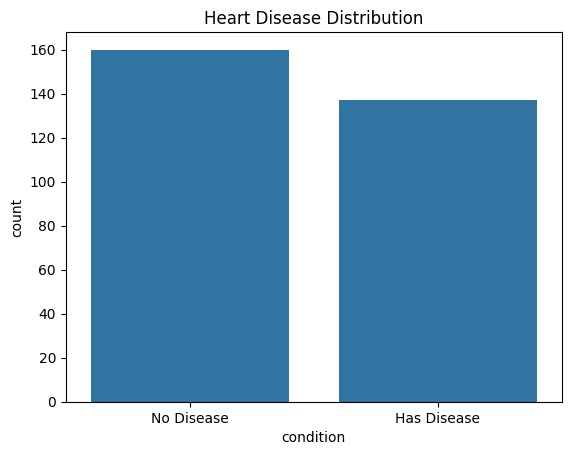

In [22]:
sns.countplot(x='condition', data=df)
plt.title('Heart Disease Distribution')
plt.xticks([0,1], ['No Disease', 'Has Disease'])
plt.show()

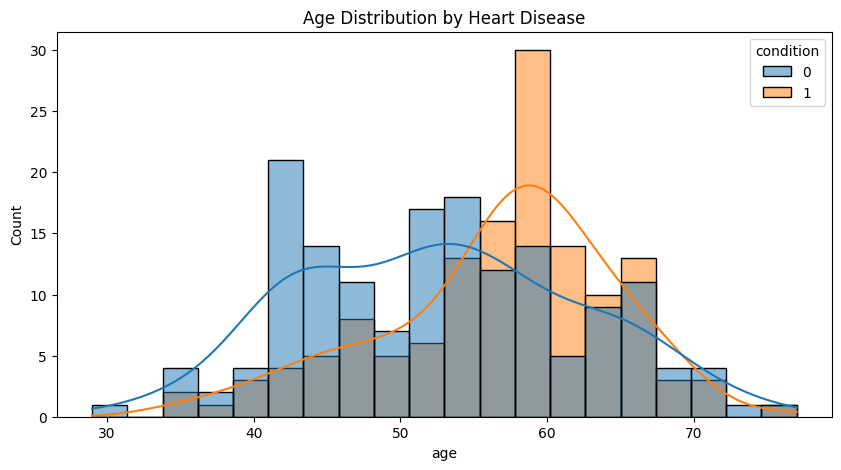

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='age', hue='condition', bins=20, kde=True)

plt.title("Age Distribution by Heart Disease")
plt.show()

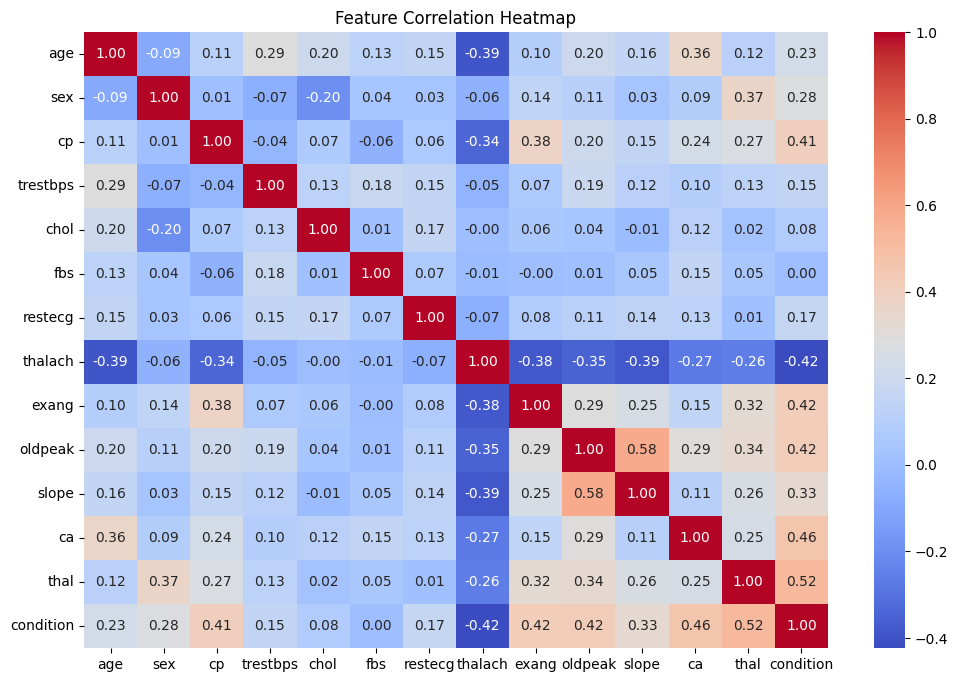

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

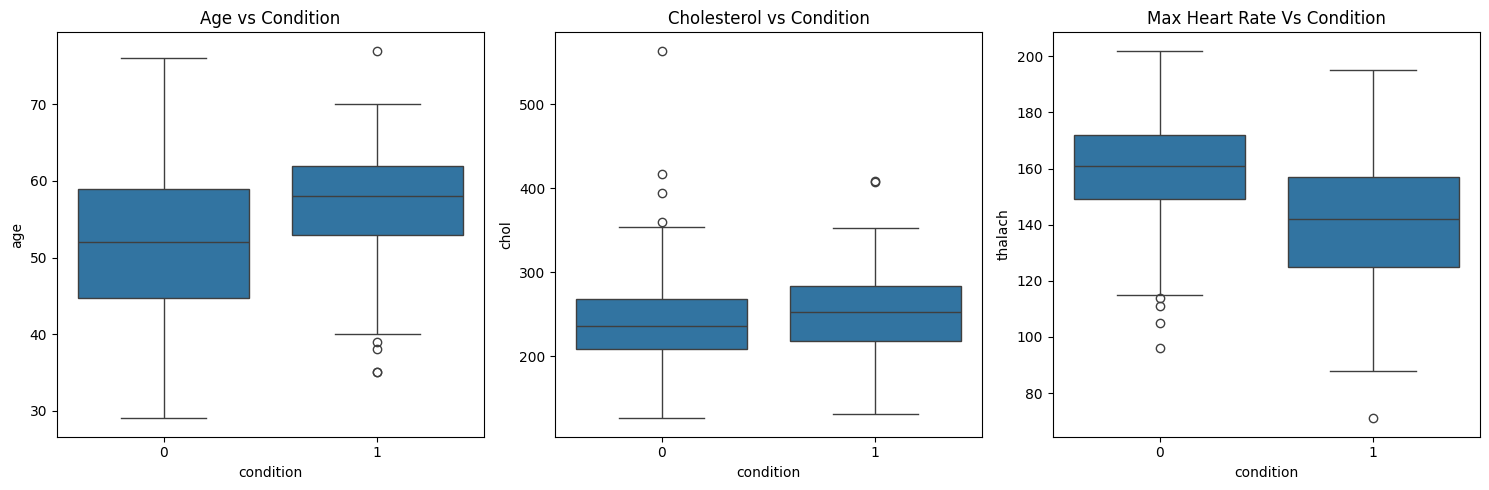

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='condition', y='age', ax=axes[0])
axes[0].set_title('Age vs Condition')

sns.boxplot(data=df, x='condition', y='chol', ax=axes[1])
axes[1].set_title('Cholesterol vs Condition')

sns.boxplot(data=df, x='condition', y='thalach', ax=axes[2])

axes[2].set_title('Max Heart Rate Vs Condition')

plt.tight_layout()
plt.show()

In [27]:
X = df.drop('condition', axis=1)

y = df['condition']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (297, 13)
y shape: (297,)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 237
Testing samples: 60


In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [36]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("First 5 predictions:", y_pred[:5])
print("First 5 actual:", y_test.values[:5])

First 5 predictions: [1 1 0 0 1]
First 5 actual: [1 1 0 0 0]


In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 73.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74        32
           1       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60



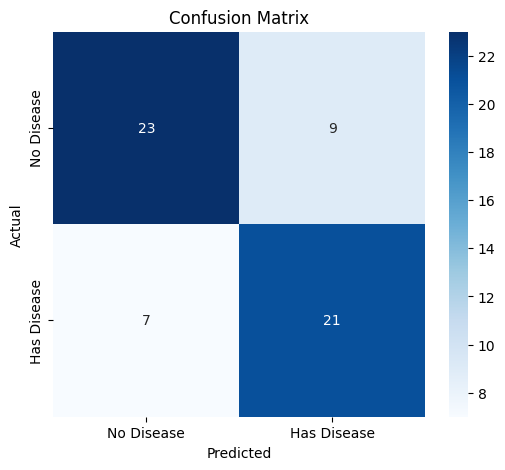

In [41]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Has Disease'], yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


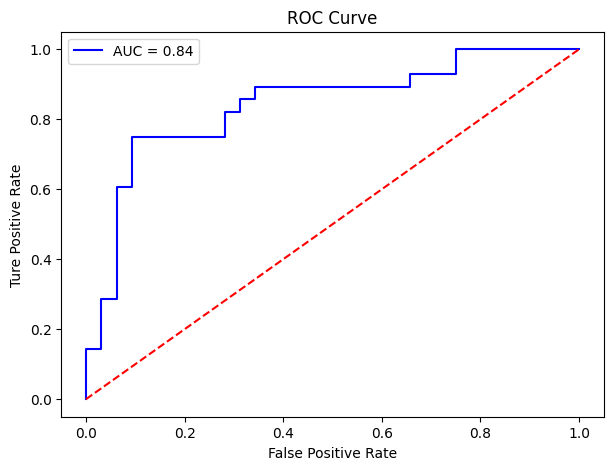

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.2f}')
plt.plot([0,1],[0,1], color='red', linestyle='--')

plt.title("ROC Curve")

plt.xlabel('False Positive Rate')

plt.ylabel('Ture Positive Rate')

plt.legend()
plt.show()

In [45]:
import numpy as np

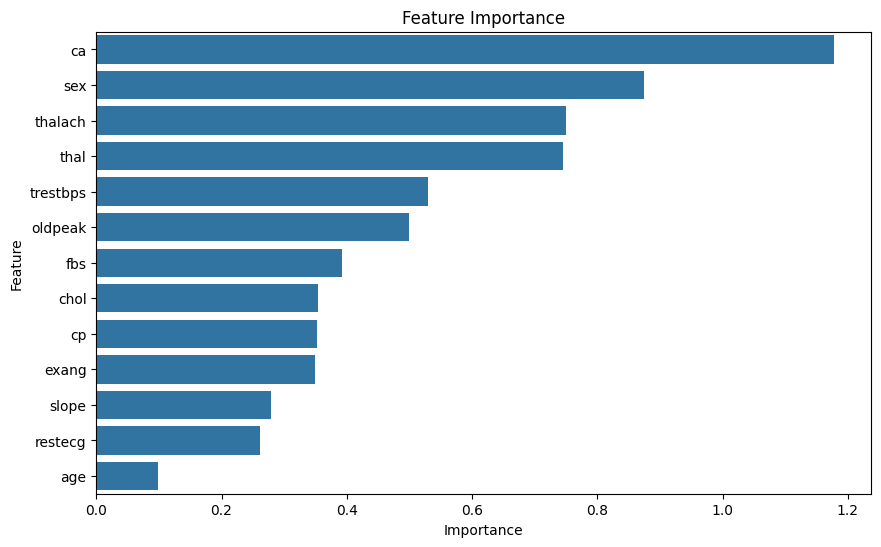

     Feature  Importance
11        ca    1.178408
1        sex    0.874545
7    thalach    0.750473
12      thal    0.744396
3   trestbps    0.528835
9    oldpeak    0.498815
5        fbs    0.392838
4       chol    0.353759
2         cp    0.352740
8      exang    0.349842
10     slope    0.278713
6    restecg    0.261820
0        age    0.099137


In [47]:
feature_names = df.drop('condition', axis=1).columns
coefficients = model.coef_[0]

feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(coefficients)}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(data=feat_importance, x='Importance', y='Feature')

plt.title('Feature Importance')

plt.show()

print(feat_importance)


